# Olist Exploratory Data Analysis

## HVIA Data & AI Solutions Task

**Prepared by:** Youssef Atef Tayh  
**Stage:** Exploratory Data Analysis & Business Findings

This notebook moves from dataset structure to business questions.

The analysis uses the Olist historical dataset and focuses on observable patterns in orders, sales-value proxies, customers, products, payments, delivery, and reviews.

## Analysis Principles

- Each question is answered with a clear metric.
- Visualizations are used only when they help explain a pattern.
- Comparisons are based on the same population and time period.
- `price` from Order Items is used as an **item sales-value proxy**. It is not Olist revenue.
- Freight is analyzed separately.
- Insights describe observed patterns; they do not claim causation without additional evidence.

# 1. Setup

In [1]:
# Data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File paths and display
from pathlib import Path
from IPython.display import display

# Hide unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

In [2]:
current_folder = Path.cwd()

if (current_folder / "data" / "raw").exists():
    PROJECT_ROOT = current_folder
elif (current_folder.parent / "data" / "raw").exists():
    PROJECT_ROOT = current_folder.parent
else:
    raise FileNotFoundError("Could not find the project data/raw folder.")

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {DATA_DIR}")

Project root: E:\Interniship\HVIA - Data & AI Intern 2026\Tasks\Daily Tasks\Task 1\Olist_HVIA_Youssef_Atef_Tayh
Raw data folder: E:\Interniship\HVIA - Data & AI Intern 2026\Tasks\Daily Tasks\Task 1\Olist_HVIA_Youssef_Atef_Tayh\data\raw


# 2. Load Data

In [3]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "translation": translation,
}

print(f"Loaded {len(tables)} tables successfully.")

Loaded 9 tables successfully.


# 3. Prepare Analysis Tables

In [4]:
# Convert order timestamps
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"], errors="coerce"
)
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"], errors="coerce"
)

# Add English category names
items_with_category = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

items_with_category = items_with_category.merge(
    translation,
    on="product_category_name",
    how="left"
)

items_with_category["category"] = (
    items_with_category["product_category_name_english"]
    .fillna(items_with_category["product_category_name"])
    .fillna("Unknown")
)

# Order-level sales and freight
order_value = (
    items_with_category
    .groupby("order_id", as_index=False)
    .agg(
        item_sales_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count"),
    )
)

# Payment totals
payment_value = (
    payments
    .groupby("order_id", as_index=False)
    .agg(payment_value=("payment_value", "sum"))
)

# Average review score per order
review_value = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

# Customer information
customer_info = customers[
    ["customer_id", "customer_unique_id", "customer_state"]
].copy()

analysis_orders = (
    orders
    .merge(customer_info, on="customer_id", how="left")
    .merge(order_value, on="order_id", how="left")
    .merge(payment_value, on="order_id", how="left")
    .merge(review_value, on="order_id", how="left")
)

analysis_orders["item_sales_value"] = analysis_orders["item_sales_value"].fillna(0)
analysis_orders["freight_value"] = analysis_orders["freight_value"].fillna(0)
analysis_orders["item_count"] = analysis_orders["item_count"].fillna(0)

analysis_orders["delivery_days"] = (
    analysis_orders["order_delivered_customer_date"]
    - analysis_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

analysis_orders["delivery_delay_days"] = (
    analysis_orders["order_delivered_customer_date"]
    - analysis_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

analysis_orders["is_late"] = analysis_orders["delivery_delay_days"] > 0

analysis_orders["purchase_month"] = (
    analysis_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

print("Analysis table shape:", analysis_orders.shape)
display(analysis_orders.head())

Analysis table shape: (99441, 19)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,item_sales_value,freight_value,item_count,payment_value,review_score,delivery_days,delivery_delay_days,is_late,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,29.99,8.72,1.0,38.71,4.0,8.436574,-7.107488,False,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,118.70,22.76,1.0,141.46,4.0,13.782037,-5.355729,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,159.90,19.22,1.0,179.12,5.0,9.394213,-17.245498,False,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,45.00,27.20,1.0,72.20,5.0,13.208750,-12.980069,False,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,19.90,8.72,1.0,28.62,5.0,2.873877,-9.238171,False,2018-02


### Analysis Table Interpretation

The analysis table keeps the order as the central grain and adds aggregated item sales value, freight, payment value, review score, customer information, and delivery metrics.

Aggregations are used before joining one-to-many tables to avoid multiplying order values.

# 4. Business Question 1 — How did order activity change over time?

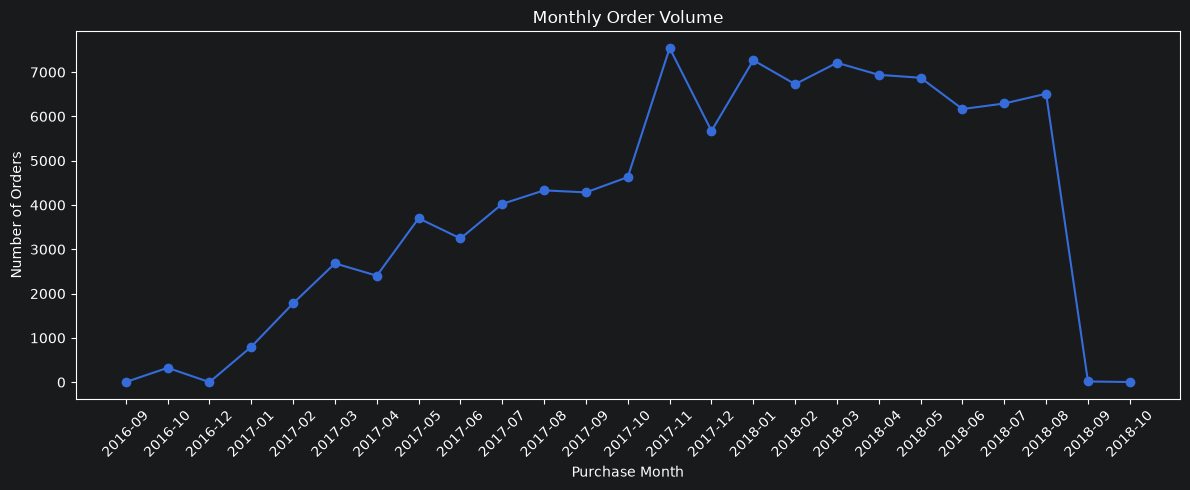

In [5]:
monthly_orders = (
    analysis_orders
    .groupby("purchase_month")
    .agg(orders=("order_id", "nunique"))
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders["purchase_month"], monthly_orders["orders"], marker="o")
plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
peak_month = monthly_orders.loc[monthly_orders["orders"].idxmax()]
lowest_month = monthly_orders.loc[monthly_orders["orders"].idxmin()]

print(
    f"Observed pattern: the highest monthly order volume was "
    f"{int(peak_month['orders']):,} orders in {peak_month['purchase_month']}."
)
print(
    f"The lowest monthly order volume in the represented period was "
    f"{int(lowest_month['orders']):,} orders in {lowest_month['purchase_month']}."
)

Observed pattern: the highest monthly order volume was 7,544 orders in 2017-11.
The lowest monthly order volume in the represented period was 1 orders in 2016-12.


### Insight

The monthly series shows how transaction activity changed across the historical period.

This is descriptive only. A change in order volume can have multiple causes, so the chart should not be interpreted as proof of a specific cause.

### Time Coverage Note

The dataset does not represent complete calendar years across the entire period. The earliest and latest periods contain partial coverage, so monthly comparisons near the boundaries should be interpreted using the available observation period.

# 5. Business Question 2 — How did item sales value change over time?

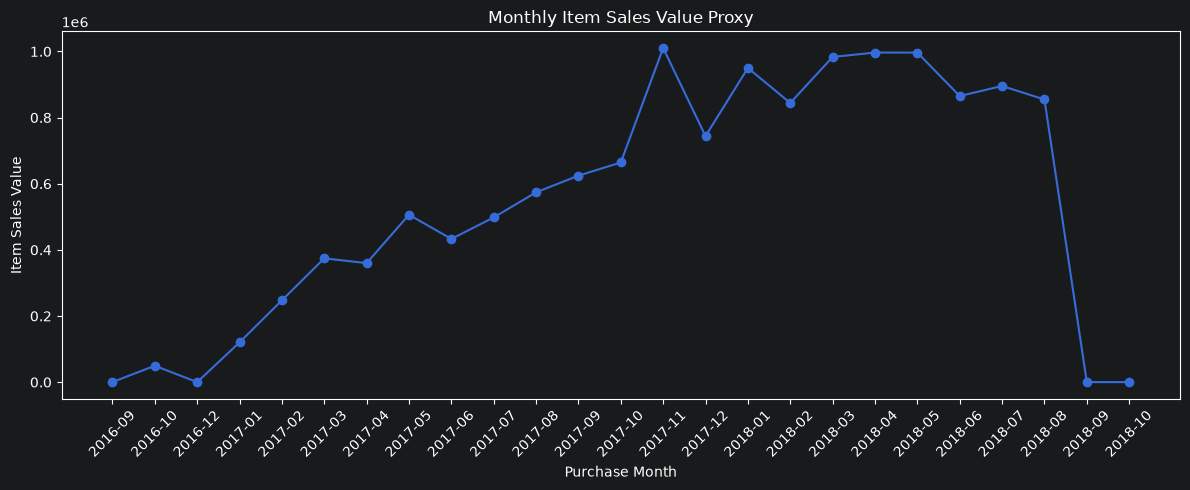

In [7]:
monthly_sales = (
    analysis_orders
    .groupby("purchase_month")
    .agg(item_sales_value=("item_sales_value", "sum"))
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["purchase_month"], monthly_sales["item_sales_value"], marker="o")
plt.title("Monthly Item Sales Value Proxy")
plt.xlabel("Purchase Month")
plt.ylabel("Item Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
peak_sales_month = monthly_sales.loc[monthly_sales["item_sales_value"].idxmax()]

print(
    f"Highest observed monthly item sales value was "
    f"{peak_sales_month['item_sales_value']:,.2f} in "
    f"{peak_sales_month['purchase_month']}."
)
print("This metric uses item price and excludes freight and Olist revenue.")

Highest observed monthly item sales value was 1,010,271.37 in 2017-11.
This metric uses item price and excludes freight and Olist revenue.


### Insight

The sales-value trend should be read together with order volume. A month can have high sales value because of more orders, higher-value baskets, or both.

# 6. Business Question 3 — What is the order-status structure?

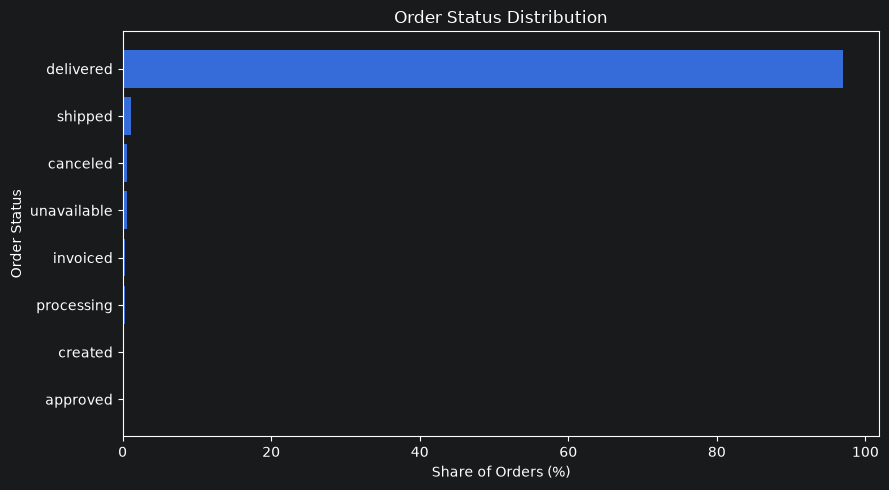

In [9]:
status_share = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("Order Status")
    .reset_index(name="Share %")
)

plt.figure(figsize=(9, 5))
plt.barh(status_share["Order Status"], status_share["Share %"])
plt.title("Order Status Distribution")
plt.xlabel("Share of Orders (%)")
plt.ylabel("Order Status")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
dominant_status = status_share.iloc[0]
print(
    f"The largest observed order-status group is '{dominant_status['Order Status']}', "
    f"representing {dominant_status['Share %']:.2f}% of orders."
)

The largest observed order-status group is 'delivered', representing 97.02% of orders.


### Insight

Order status distribution gives a high-level view of the historical transaction lifecycle. The status mix is a useful baseline for later operational analysis.

# 7. Business Question 4 — Which product categories account for the most item sales value?

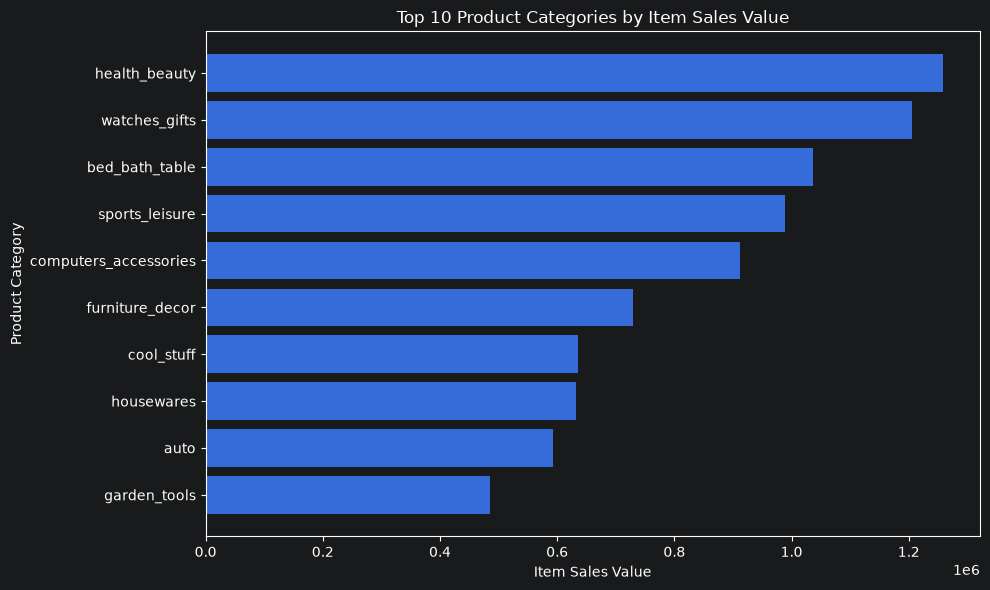

In [11]:
category_sales = (
    items_with_category
    .groupby("category", as_index=False)
    .agg(
        item_sales_value=("price", "sum"),
        items=("order_item_id", "count")
    )
    .sort_values("item_sales_value", ascending=False)
)

top_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["category"], top_categories["item_sales_value"])
plt.title("Top 10 Product Categories by Item Sales Value")
plt.xlabel("Item Sales Value")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
top_category = top_categories.iloc[0]

print(
    f"The highest item sales value among categories is observed for "
    f"'{top_category['category']}', with {top_category['item_sales_value']:,.2f}."
)
print("This is item sales value based on the price field, not Olist revenue.")

The highest item sales value among categories is observed for 'health_beauty', with 1,258,681.34.
This is item sales value based on the price field, not Olist revenue.


### Insight

Category sales concentration can help identify where assortment and commercial analysis may be most useful. The result describes historical transaction value and does not establish profitability.

# 8. Business Question 5 — Which customer states have the most orders?

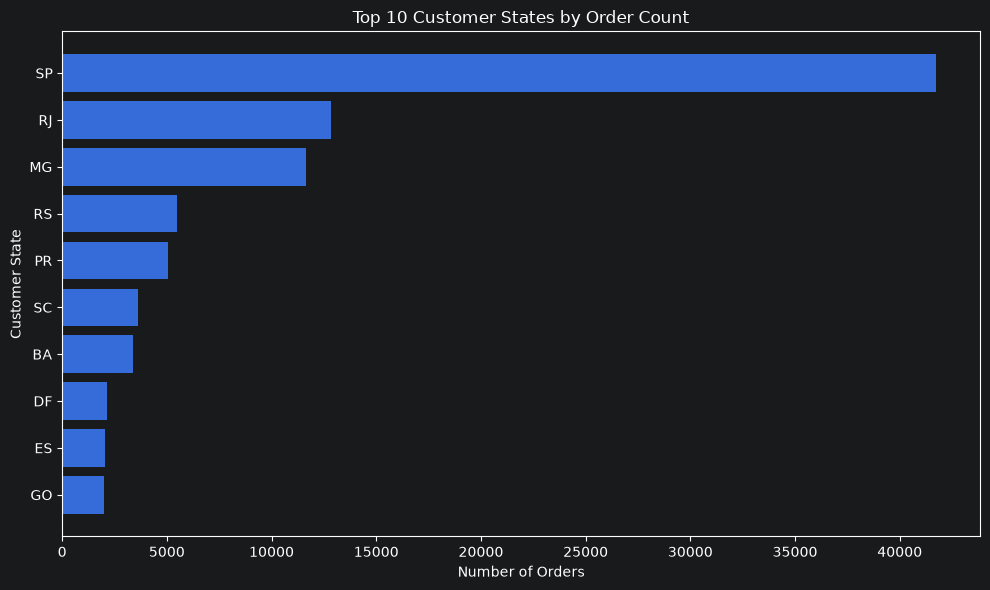

In [13]:
state_orders = (
    analysis_orders
    .groupby("customer_state", as_index=False)
    .agg(orders=("order_id", "nunique"))
    .sort_values("orders", ascending=False)
)

top_states = state_orders.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_states["customer_state"], top_states["orders"])
plt.title("Top 10 Customer States by Order Count")
plt.xlabel("Number of Orders")
plt.ylabel("Customer State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
top_state = top_states.iloc[0]

print(
    f"The state with the highest observed order count is {top_state['customer_state']}, "
    f"with {int(top_state['orders']):,} orders."
)
print("This describes order concentration by customer location.")

The state with the highest observed order count is SP, with 41,746 orders.
This describes order concentration by customer location.


### Insight

Customer order volume is geographically concentrated. This can be relevant to later logistics, service-level, and regional demand analysis.

# 9. Business Question 6 — Which payment methods are most common?

In [15]:
payment_method_records = (
    payments["payment_type"]
    .value_counts()
    .rename_axis("Payment Type")
    .reset_index(name="Payment Records")
)

order_payment_method = (
    payments
    .groupby("order_id")["payment_type"]
    .first()
    .value_counts()
    .rename_axis("Payment Type")
    .reset_index(name="Orders")
)

display(payment_method_records)
display(order_payment_method)

,Payment Type,Payment Records
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


,Payment Type,Orders
0,credit_card,75387
1,boleto,19784
2,voucher,2739
3,debit_card,1527
4,not_defined,3


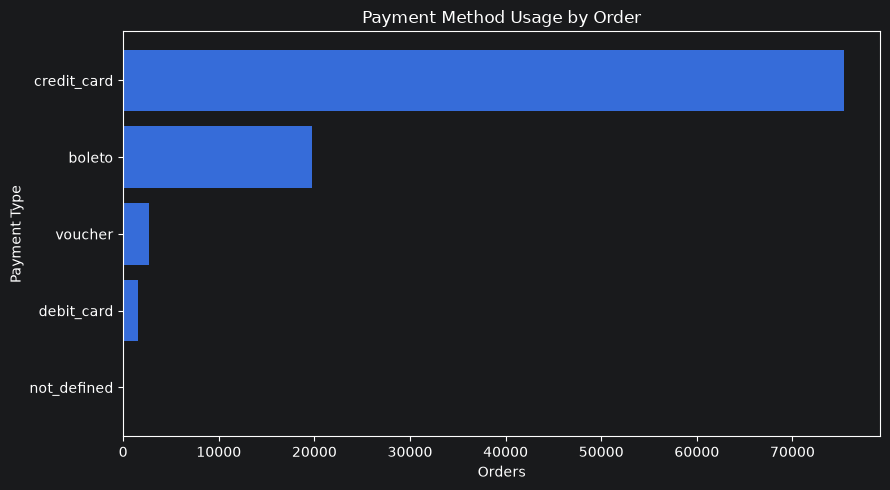

In [16]:
plt.figure(figsize=(9, 5))

plt.barh(
    order_payment_method["Payment Type"],
    order_payment_method["Orders"]
)

plt.title("Payment Method Usage by Order")
plt.xlabel("Orders")
plt.ylabel("Payment Type")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
top_payment = order_payment_method.iloc[0]

print(
    f"The most frequent payment type at the order level is "
    f"'{top_payment['Payment Type']}', with {int(top_payment['Orders']):,} orders."
)
print("Payment records are shown separately because one order can have multiple payment records.")

The most frequent payment type at the order level is 'credit_card', with 75,387 orders.
Payment records are shown separately because one order can have multiple payment records.


### Insight

Payment-method mix is relevant to checkout design and payment operations. Payment record counts should not be interpreted as unique customers or unique orders because one order can contain multiple payment records.

# 10. Business Question 7 — Does delivery performance differ by review score?

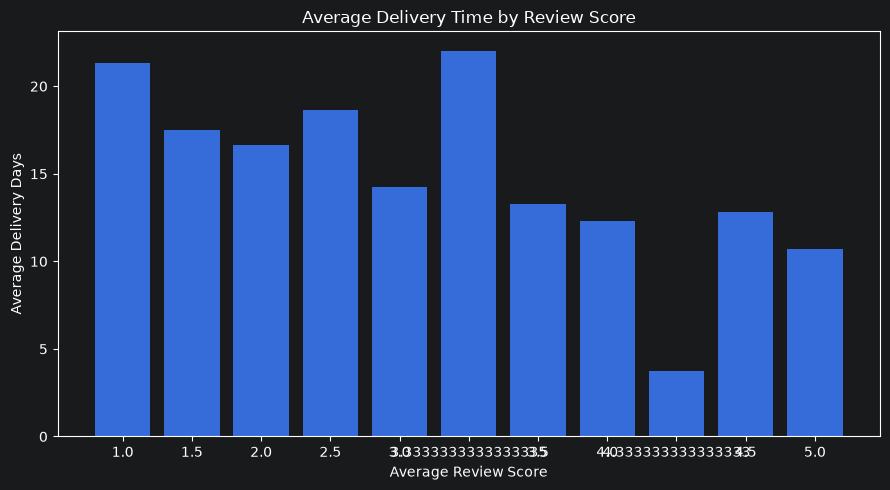

In [18]:
delivered_orders = analysis_orders[
    analysis_orders["delivery_days"].notna()
    & analysis_orders["review_score"].notna()
].copy()

delivery_by_review = (
    delivered_orders
    .groupby("review_score", as_index=False)
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "nunique")
    )
)

plt.figure(figsize=(9, 5))
plt.bar(
    delivery_by_review["review_score"].astype(str),
    delivery_by_review["average_delivery_days"]
)
plt.title("Average Delivery Time by Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Average Delivery Days")
plt.tight_layout()
plt.show()

In [19]:
print(
    "This comparison is descriptive. It shows whether review-score groups "
    "have different observed delivery times."
)

display(delivery_by_review.round(2))

This comparison is descriptive. It shows whether review-score groups have different observed delivery times.


,review_score,average_delivery_days,orders
0,1.00,21.34,9316
1,1.50,17.53,8
2,2.00,16.66,2916
3,2.50,18.67,30
4,3.00,14.25,7916
5,3.33,22.03,1
6,3.50,13.28,23
7,4.00,12.31,18868
8,4.33,3.77,1
9,4.50,12.80,53


### Insight

Differences in average delivery time across review-score groups can indicate a relationship worth investigating.

This analysis does not prove that delivery time caused the review score because other factors may influence customer satisfaction.

# 11. Business Question 8 — How common are repeat customers?

In [20]:
customer_orders = (
    analysis_orders
    .groupby("customer_unique_id")
    .agg(order_count=("order_id", "nunique"))
    .reset_index()
)

customer_orders["customer_type"] = np.where(
    customer_orders["order_count"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_type_summary = (
    customer_orders["customer_type"]
    .value_counts()
    .rename_axis("Customer Type")
    .reset_index(name="Customers")
)

customer_type_summary["Share %"] = (
    customer_type_summary["Customers"]
    / customer_type_summary["Customers"].sum()
    * 100
).round(2)

display(customer_type_summary)

,Customer Type,Customers,Share %
0,One-Time Customer,93099,96.88
1,Repeat Customer,2997,3.12


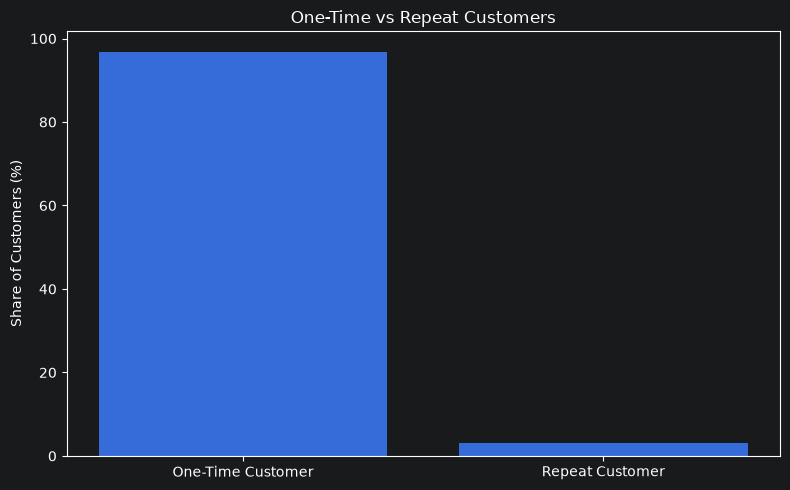

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(customer_type_summary["Customer Type"], customer_type_summary["Share %"])
plt.title("One-Time vs Repeat Customers")
plt.xlabel("")
plt.ylabel("Share of Customers (%)")
plt.tight_layout()
plt.show()

In [22]:
repeat_share = customer_type_summary.loc[
    customer_type_summary["Customer Type"] == "Repeat Customer", "Share %"
].iloc[0]

print(f"Repeat customers represent {repeat_share:.2f}% of unique customers in the dataset.")
print("Customer retention should be investigated further with time-aware cohort analysis.")

Repeat customers represent 3.12% of unique customers in the dataset.
Customer retention should be investigated further with time-aware cohort analysis.


### Insight

The observed customer mix provides a baseline for retention analysis. The dataset can support deeper cohort and repeat-purchase analysis without assuming why customers returned or did not return.

# 12. Business Question 9 — How often were orders delivered after the estimated date?

In [23]:
delivered = analysis_orders[
    analysis_orders["order_delivered_customer_date"].notna()
].copy()

delivery_summary = pd.DataFrame([
    ["Delivered orders", len(delivered)],
    ["Late deliveries", int(delivered["is_late"].sum())],
    ["Late delivery rate (%)", round(delivered["is_late"].mean() * 100, 2)],
    ["Average delivery days", round(delivered["delivery_days"].mean(), 2)],
    ["Median delivery days", round(delivered["delivery_days"].median(), 2)],
], columns=["Metric", "Value"])

display(delivery_summary)

,Metric,Value
0,Delivered orders,96476.00
1,Late deliveries,7827.00
2,Late delivery rate (%),8.11
3,Average delivery days,12.56
4,Median delivery days,10.22


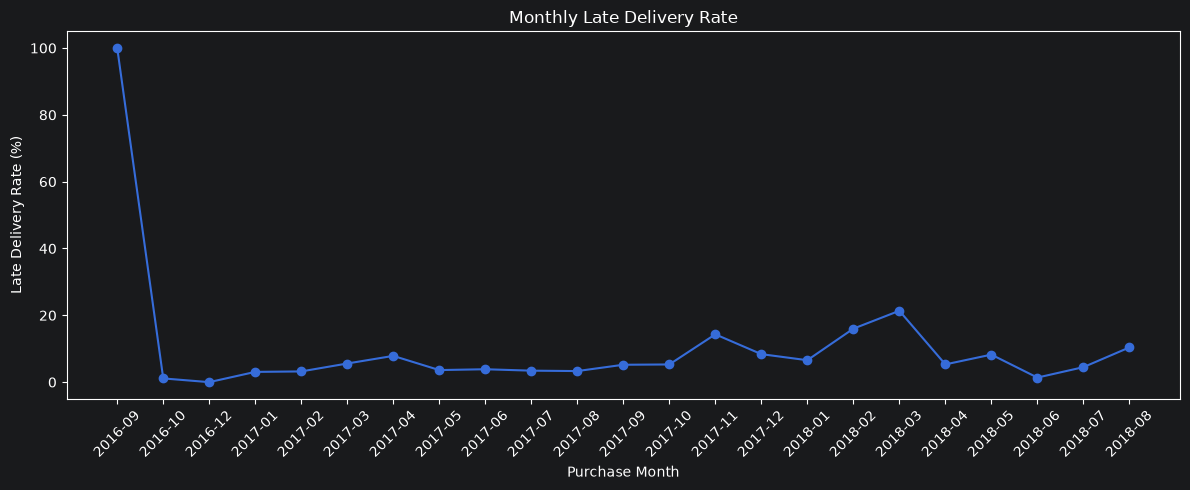

In [24]:
late_by_month = (
    delivered
    .groupby("purchase_month")
    .agg(
        orders=("order_id", "nunique"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

late_by_month["late_rate"] = late_by_month["late_rate"] * 100

plt.figure(figsize=(12, 5))
plt.plot(late_by_month["purchase_month"], late_by_month["late_rate"], marker="o")
plt.title("Monthly Late Delivery Rate")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
minimum_delivered_orders = 100

late_by_month_filtered = late_by_month[
    late_by_month["orders"] >= minimum_delivered_orders
].copy()

highest_late_month = late_by_month_filtered.loc[
    late_by_month_filtered["late_rate"].idxmax()
]

print(
    f"The highest observed monthly late-delivery rate among months with at least "
    f"{minimum_delivered_orders} delivered orders was "
    f"{highest_late_month['late_rate']:.2f}% in "
    f"{highest_late_month['purchase_month']}."
)
print(
    f"That month contained {int(highest_late_month['orders']):,} delivered orders."
)
print("A late delivery is defined here as customer delivery after the estimated delivery date.")

The highest observed monthly late-delivery rate among months with at least 100 delivered orders was 21.36% in 2018-03.
That month contained 7,003 delivered orders.
A late delivery is defined here as customer delivery after the estimated delivery date.


### Insight

Delivery timing is a measurable operational dimension in the dataset.

Late-delivery rate can later be combined with seller, region, product category, and order characteristics to identify operational patterns.

# 13. Business Question 10 — What is the average item sales value per order?

Average order value is calculated from item price associated with each order. This is an item-sales-value proxy and should not be interpreted as Olist revenue.

In [26]:
order_value_summary = pd.DataFrame({
    "total_item_sales_value": [analysis_orders["item_sales_value"].sum()],
    "total_orders": [analysis_orders["order_id"].nunique()]
})

order_value_summary["average_order_value"] = (
    order_value_summary["total_item_sales_value"]
    / order_value_summary["total_orders"]
)

display(order_value_summary.round(2))

,total_item_sales_value,total_orders,average_order_value
0,13591643.7,99441,136.68


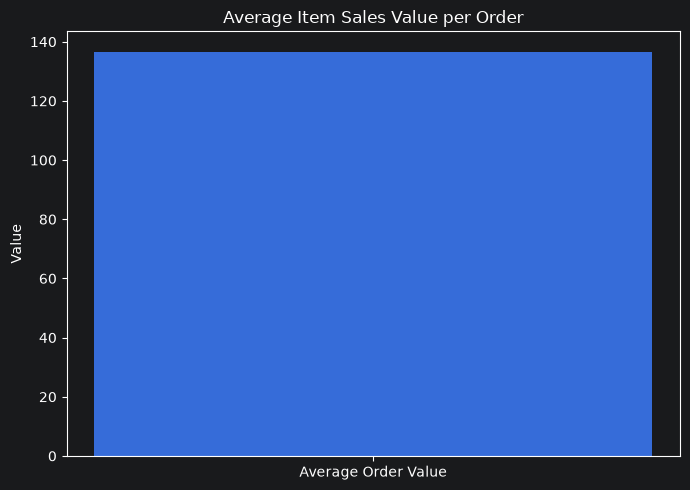

In [27]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Average Order Value"],
    [float(order_value_summary["average_order_value"].iloc[0])]
)

plt.title("Average Item Sales Value per Order")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [28]:
average_order_value = order_value_summary["average_order_value"].iloc[0]

print(
    f"The average item sales value per order is {average_order_value:,.2f}."
)
print(
    "This metric represents item price value per order and is not Olist revenue."
)

The average item sales value per order is 136.68.
This metric represents item price value per order and is not Olist revenue.


# 14. Business Question 11 — How significant is freight value relative to item sales value?

Freight value is compared with item sales value to understand the relative shipping cost represented in the dataset. This is descriptive and does not represent Olist logistics profit or margin.

In [29]:
freight_summary = pd.DataFrame({
    "total_item_sales_value": [analysis_orders["item_sales_value"].sum()],
    "total_freight_value": [analysis_orders["freight_value"].sum()]
})

freight_summary["freight_to_sales_ratio"] = (
    freight_summary["total_freight_value"]
    / freight_summary["total_item_sales_value"]
    * 100
)

display(freight_summary.round(2))

,total_item_sales_value,total_freight_value,freight_to_sales_ratio
0,13591643.7,2251909.54,16.57


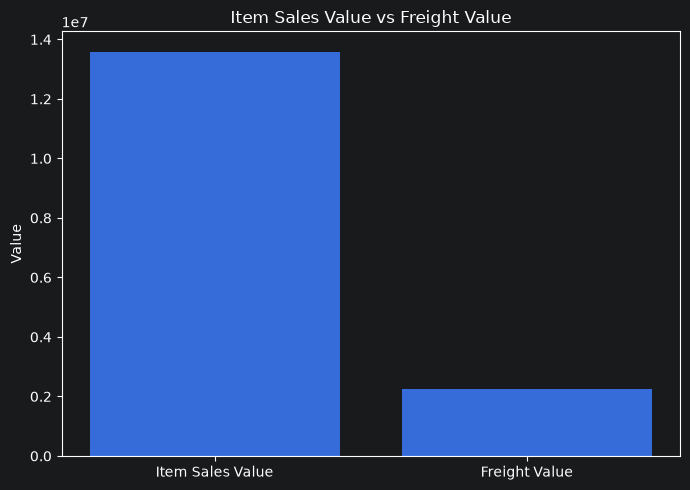

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Item Sales Value", "Freight Value"],
    [
        float(freight_summary["total_item_sales_value"].iloc[0]),
        float(freight_summary["total_freight_value"].iloc[0])
    ]
)

plt.title("Item Sales Value vs Freight Value")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [31]:
freight_ratio = freight_summary["freight_to_sales_ratio"].iloc[0]

print(
    f"Freight value represents approximately {freight_ratio:.2f}% "
    "of item sales value in the dataset.")

print("This ratio can support later logistics and pricing analysis.")

Freight value represents approximately 16.57% of item sales value in the dataset.
This ratio can support later logistics and pricing analysis.


# 15. Business Question 12 — How is item sales value distributed across sellers?

Seller-level analysis helps identify concentration of item sales value across the seller ecosystem. The metric uses item price and does not represent seller profit or Olist revenue.

In [32]:
seller_sales = (
    order_items
    .groupby("seller_id", as_index=False)
    .agg(
        item_sales_value=("price", "sum"),
        items=("order_item_id", "count")
    )
    .sort_values("item_sales_value", ascending=False)
)

top_sellers = seller_sales.head(10)

display(top_sellers)

,seller_id,item_sales_value,items
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156
1013,53243585a1d6dc2643021fd1853d8905,222776.05,410
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1987
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,340
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1551
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1171
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1428
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1499


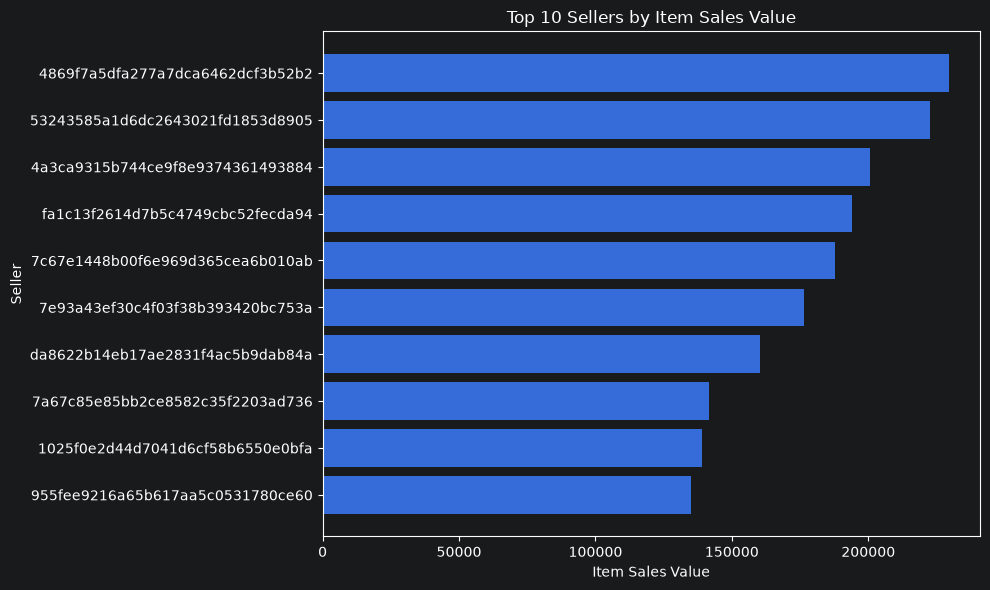

In [33]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_sellers["seller_id"],
    top_sellers["item_sales_value"]
)

plt.title("Top 10 Sellers by Item Sales Value")
plt.xlabel("Item Sales Value")
plt.ylabel("Seller")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [34]:
top_seller = top_sellers.iloc[0]

print(
    f"The seller with the highest observed item sales value is "
    f"{top_seller['seller_id']} with {top_seller['item_sales_value']:,.2f}."
)
print("Seller concentration can support later marketplace and seller-performance analysis.")

The seller with the highest observed item sales value is 4869f7a5dfa277a7dca6462dcf3b52b2 with 229,472.63.
Seller concentration can support later marketplace and seller-performance analysis.


# 16. Business Question 13 — How are customer review scores distributed?

Review scores provide a descriptive view of customer feedback across transactions represented in the dataset.

In [35]:
review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("Review Score")
    .reset_index(name="Reviews")
)

display(review_distribution)

,Review Score,Reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


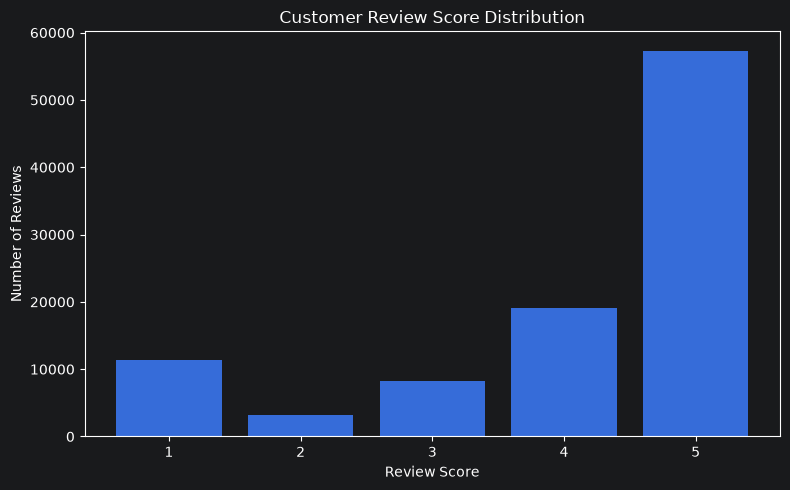

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution["Review Score"].astype(str),
    review_distribution["Reviews"]
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [37]:
most_common_review = review_distribution.loc[
    review_distribution["Reviews"].idxmax()
]

print(
    f"The most common review score is {int(most_common_review['Review Score'])}, "
    f"with {int(most_common_review['Reviews']):,} reviews."
)

The most common review score is 5, with 57,328 reviews.


# 17. Key Business Findings

The findings below summarize observed patterns in the historical dataset. They are evidence for further business discovery, not proof of current Olist operational problems.

# 17. Key Business Findings

In [38]:
findings = pd.DataFrame([
    ["Demand trend", f"Monthly order activity varies across the historical period, with a peak of {int(peak_month['orders']):,} orders in {peak_month['purchase_month']} within the represented period."],
    ["Sales-value concentration", f"The highest category-level item sales value is observed in {top_category['category']} within the analyzed records."],
    ["Geographic concentration", f"{top_state['customer_state']} has the highest customer-order count in the dataset."],
    ["Payment mix", f"{top_payment['Payment Type']} is the most frequent payment type at the order level."],
    ["Customer retention", f"Repeat customers represent {repeat_share:.2f}% of unique customers."],
    ["Delivery", f"The overall observed late-delivery rate is {delivery_summary.loc[delivery_summary['Metric']=='Late delivery rate (%)','Value'].iloc[0]:.2f}% among delivered orders."],
    ["Average order value", f"Average item sales value per order is {average_order_value:,.2f}."],
    ["Freight", f"Freight value represents {freight_ratio:.2f}% of item sales value."],
    ["Seller concentration", f"The top observed seller by item sales value is {top_seller['seller_id']}."],
    ["Review distribution", f"The most common review score is {int(most_common_review['Review Score'])}."],
], columns=["Area", "Observed Finding"])

display(findings)

,Area,Observed Finding
0,Demand trend,Monthly order activity varies across the histo...
1,Sales-value concentration,The highest category-level item sales value is...
2,Geographic concentration,SP has the highest customer-order count in the...
3,Payment mix,credit_card is the most frequent payment type ...
4,Customer retention,Repeat customers represent 3.12% of unique cus...
5,Delivery,The overall observed late-delivery rate is 8.1...
6,Average order value,Average item sales value per order is 136.68.
7,Freight,Freight value represents 16.57% of item sales ...
8,Seller concentration,The top observed seller by item sales value is...
9,Review distribution,The most common review score is 5.


### Business Interpretation

The findings point to several areas where data can support decisions:

- Demand monitoring can help understand order-volume changes.
- Category analysis can support assortment and commercial planning.
- Geographic concentration can support regional operations and logistics analysis.
- Payment mix can support checkout and payment operations.
- Repeat-customer analysis can support retention measurement.
- Delivery performance can support logistics and service-level monitoring.

These observations describe opportunities for further analysis. They are not predictions or causal claims.

# 18. Limitations

- The dataset represents a historical period from 2016–2018.
- The dataset does not provide Olist's internal revenue or profit statement.
- `price` is used as an item sales-value proxy, not Olist revenue.
- Correlation or descriptive differences do not prove causation.
- The dataset contains marketplace transaction records and may not represent every Olist operation.
- Further analysis should validate findings by seller, region, category, and time period.

# 19. Next Stage

The next step is to translate these findings into:

1. Business questions for Olist.
2. Data / AI solution opportunities.
3. A practical HVIA proposal.
4. Supporting evidence for outreach.

# 19. Business Questions for Olist

The findings from the historical dataset are used to define discovery questions for Olist.

These questions are not assumptions about Olist's current operations. They are questions that could be validated with Olist stakeholders before proposing a production solution.

In [39]:
business_questions = pd.DataFrame([
    ["Demand monitoring", "How does Olist currently monitor changes in order demand by month, category, region, and seller?"],
    ["Delivery performance", "How are late deliveries currently identified, investigated, and communicated to operational teams?"],
    ["Seller performance", "Which seller-level indicators are currently used to monitor sales activity and operational performance?"],
    ["Customer retention", "How does Olist currently measure repeat purchasing and customer retention?"],
    ["Freight", "How does Olist monitor freight value relative to item sales value across regions, sellers, and categories?"],
    ["Payment operations", "Which payment methods and payment patterns require the most operational monitoring?"],
    ["Reviews", "How are customer reviews and low scores incorporated into operational improvement?"],
    ["Forecasting", "Which demand, delivery, or seller metrics would benefit from forecasting or predictive alerts?"],
    ["Decision support", "Which recurring decisions currently require manual reporting or repeated data preparation?"],
    ["Data platform", "How are marketplace, seller, customer, order, payment, and logistics data currently integrated for reporting?"],
], columns=["Area", "Discovery Question"])

display(business_questions)

,Area,Discovery Question
0,Demand monitoring,How does Olist currently monitor changes in or...
1,Delivery performance,"How are late deliveries currently identified, ..."
2,Seller performance,Which seller-level indicators are currently us...
3,Customer retention,How does Olist currently measure repeat purcha...
4,Freight,How does Olist monitor freight value relative ...
5,Payment operations,Which payment methods and payment patterns req...
6,Reviews,How are customer reviews and low scores incorp...
7,Forecasting,"Which demand, delivery, or seller metrics woul..."
8,Decision support,Which recurring decisions currently require ma...
9,Data platform,"How are marketplace, seller, customer, order, ..."


### Why these questions matter

The questions connect the observed dataset patterns to decisions that a Data and AI solution could potentially support.

They should be validated through a discovery conversation rather than presented as confirmed current business problems.

# 20. Data / AI Solution Opportunities

The following opportunities translate the observed historical evidence into areas for further investigation.

The proposed solutions are intentionally framed as opportunities rather than claims about Olist's current systems.

In [40]:
solution_opportunities = pd.DataFrame([
    ["Demand Intelligence",
     "Monthly order variation and item-sales-value variation",
     "Demand dashboards, trend monitoring, forecasting",
     "Analytics and Forecasting"],
    ["Seller Intelligence",
     "Seller-level item-sales-value concentration",
     "Seller performance dashboards, alerts, segmentation",
     "Analytics and Decision Systems"],
    ["Logistics Intelligence",
     "Observed late deliveries and delivery-time variation",
     "Delivery monitoring, delay-risk scoring, operational alerts",
     "Logistics Intelligence"],
    ["Customer Intelligence",
     "Repeat-customer share and customer-order structure",
     "Customer segmentation, retention monitoring, propensity models",
     "Customer Intelligence"],
    ["Freight Intelligence",
     "Freight value relative to item sales value",
     "Regional and seller freight monitoring, anomaly detection",
     "Logistics Intelligence"],
    ["Review Intelligence",
     "Review-score distribution and delivery/review relationship",
     "Review monitoring, issue prioritization, text analytics extension",
     "AI-Assisted Operations"],
    ["Marketplace Data Platform",
     "Nine related marketplace, seller, customer, payment, and logistics tables",
     "Automated pipelines, governed analytical model, Power BI datasets",
     "Automation and Data Pipelines"],
], columns=[
    "Opportunity",
    "Historical Evidence",
    "Potential Capability",
    "HVIA Solution Area"
])

display(solution_opportunities)

,Opportunity,Historical Evidence,Potential Capability,HVIA Solution Area
0,Demand Intelligence,Monthly order variation and item-sales-value v...,"Demand dashboards, trend monitoring, forecasting",Analytics and Forecasting
1,Seller Intelligence,Seller-level item-sales-value concentration,"Seller performance dashboards, alerts, segment...",Analytics and Decision Systems
2,Logistics Intelligence,Observed late deliveries and delivery-time var...,"Delivery monitoring, delay-risk scoring, opera...",Logistics Intelligence
3,Customer Intelligence,Repeat-customer share and customer-order struc...,"Customer segmentation, retention monitoring, p...",Customer Intelligence
4,Freight Intelligence,Freight value relative to item sales value,"Regional and seller freight monitoring, anomal...",Logistics Intelligence
5,Review Intelligence,Review-score distribution and delivery/review ...,"Review monitoring, issue prioritization, text ...",AI-Assisted Operations
6,Marketplace Data Platform,"Nine related marketplace, seller, customer, pa...","Automated pipelines, governed analytical model...",Automation and Data Pipelines


### Opportunity interpretation

The strongest opportunity areas are those where the dataset already demonstrates a measurable pattern and where a recurring business decision could be supported by better data availability, monitoring, or prediction.

The next step would be to validate priorities, available live data, existing systems, and operational ownership with Olist.

# 21. Practical HVIA Proposal

## Olist Marketplace Intelligence Platform

A practical proposal would combine a governed data foundation, decision dashboards, and optional predictive AI capabilities.

### Phase 1 — Data Foundation

- Ingest marketplace and operational data.
- Build automated data-quality checks.
- Create a consistent analytical data model.
- Maintain historical snapshots for trend analysis.

### Phase 2 — Analytics and Decision Systems

- Executive KPI dashboard.
- Seller performance dashboard.
- Customer and retention dashboard.
- Logistics and delivery dashboard.
- Automated operational reporting.

### Phase 3 — AI Extensions

- Demand forecasting.
- Delivery-delay risk scoring.
- Customer retention propensity.
- Seller anomaly detection.
- Review and customer-feedback intelligence.

### Phase 4 — Operational Integration

- Alerts for threshold breaches.
- Scheduled decision reports.
- Integration with existing operational workflows.
- Monitoring of model and data quality.

In [41]:
proposal_architecture = [
    "Olist Data Sources",
    "Data Ingestion",
    "Data Quality and Validation",
    "Analytical Data Model",
    "Power BI and Decision Dashboards",
    "AI / ML Services",
    "Alerts and Operational Workflows",
]

for step in proposal_architecture:
    print(step)

    if step != proposal_architecture[-1]:
        print("        ↓")

Olist Data Sources
        ↓
Data Ingestion
        ↓
Data Quality and Validation
        ↓
Analytical Data Model
        ↓
Power BI and Decision Dashboards
        ↓
AI / ML Services
        ↓
Alerts and Operational Workflows


### Proposed business value

The proposal is designed to help Olist move from recurring manual reporting toward a more consistent decision-support layer.

Potential value areas include:

- Faster access to operational KPIs.
- Earlier visibility into delivery and demand changes.
- Better seller and marketplace monitoring.
- More consistent customer-retention measurement.
- A reusable data foundation for future AI solutions.

These are expected value areas to validate, not measured outcomes from the historical dataset.

# 22. Supporting Evidence for Outreach

The outreach should use a small number of concrete findings rather than presenting the entire analysis.

The evidence below is generated from the historical dataset and is intended to open a discovery conversation.

In [42]:
outreach_evidence = pd.DataFrame([
    ["Demand", f"Monthly order volume varies across the represented historical period, with a peak of {int(peak_month['orders']):,} orders in {peak_month['purchase_month']}."],
    ["Customer", f"Repeat customers represent {repeat_share:.2f}% of unique customers in the analyzed historical records."],
    ["Delivery", f"The observed late-delivery rate among delivered orders is {delivery_summary.loc[delivery_summary['Metric']=='Late delivery rate (%)','Value'].iloc[0]:.2f}%."],
    ["Freight", f"Freight value represents approximately {freight_ratio:.2f}% of item sales value in the dataset."],
    ["Seller ecosystem", f"The highest observed seller item-sales value is {top_seller['item_sales_value']:,.2f} for seller {top_seller['seller_id']}."],
    ["Reviews", f"The most common customer review score is {int(most_common_review['Review Score'])}, with {int(most_common_review['Reviews']):,} reviews."],
], columns=["Evidence Area", "Historical Evidence"])

display(outreach_evidence)

,Evidence Area,Historical Evidence
0,Demand,Monthly order volume varies across the represe...
1,Customer,Repeat customers represent 3.12% of unique cus...
2,Delivery,The observed late-delivery rate among delivere...
3,Freight,Freight value represents approximately 16.57% ...
4,Seller ecosystem,The highest observed seller item-sales value i...
5,Reviews,"The most common customer review score is 5, wi..."


# 23. Final Analysis Summary

The project has now moved through the complete analytical flow:

1. Historical company research.
2. Dataset understanding.
3. Data quality assessment.
4. Exploratory analysis.
5. Business findings.
6. Business discovery questions.
7. Data / AI opportunity mapping.
8. Practical HVIA solution proposal.
9. Supporting evidence for outreach.

The findings are based on the historical Olist dataset and should be validated against current Olist data and stakeholder knowledge before implementation.

In [43]:
final_project_checklist = pd.DataFrame([
    ["Historical company context", "Complete"],
    ["Dataset structure", "Complete"],
    ["Data quality checks", "Complete"],
    ["Exploratory analysis", "Complete"],
    ["Business findings", "Complete"],
    ["Business discovery questions", "Complete"],
    ["Data / AI opportunity mapping", "Complete"],
    ["HVIA proposal", "Complete"],
    ["Outreach evidence", "Complete"],
    ["Outreach draft", "Complete"],
], columns=["Project Component", "Status"])

display(final_project_checklist)

,Project Component,Status
0,Historical company context,Complete
1,Dataset structure,Complete
2,Data quality checks,Complete
3,Exploratory analysis,Complete
4,Business findings,Complete
5,Business discovery questions,Complete
6,Data / AI opportunity mapping,Complete
7,HVIA proposal,Complete
8,Outreach evidence,Complete
9,Outreach draft,Complete
